# Question 1: Speed of Light (Michelson's 1879 Experiment)

In [12]:
# (a) Load Michelson's 1879 dataset and state the hypothesis testing framework
import json
import numpy as np
import pandas as pd
from scipy import stats

# Load experiment determinations from the JSON file
with open('michelson_speed_of_light.json', 'r') as json_file:
    michelson_payload = json.load(json_file)

# Extract individual speed measurements (in km/s)
michelson_velocities = pd.Series(
    [entry['measured_speed_kmpersec'] for entry in michelson_payload['observations']],
    name='speed_km_s'
)

# Reference benchmark: true speed of light in air (km/s)
accepted_c_air = 299734.5
significance_alpha = 0.05

print(f"Sample size (n): {len(michelson_velocities)}")
print(f"Accepted value (speed of light in air): {accepted_c_air:,.1f} km/s")
print(f"Significance threshold (alpha): {significance_alpha}")
print("\nHypotheses:")
print("  Null Hypothesis (H0): mu = 299,734.5 km/s (Apparatus exhibits no systematic bias)")
print("  Alternative Hypothesis (H1): mu != 299,734.5 km/s (Measurements deviate from accepted value)")
print("  Test Directionality: Two-tailed (systematic errors could overestimate or underestimate)")

Sample size (n): 20
Accepted value (speed of light in air): 299,734.5 km/s
Significance threshold (alpha): 0.05

Hypotheses:
  Null Hypothesis (H0): mu = 299,734.5 km/s (Apparatus exhibits no systematic bias)
  Alternative Hypothesis (H1): mu != 299,734.5 km/s (Measurements deviate from accepted value)
  Test Directionality: Two-tailed (systematic errors could overestimate or underestimate)


In [13]:
# (b) Assess normality of the sample using the Shapiro-Wilk test

# Perform the Shapiro-Wilk test on the 20 speed determinations
shapiro_w, shapiro_p = stats.shapiro(michelson_velocities)

print(f"Sample size: {len(michelson_velocities)}")
print(f"Shapiro-Wilk test statistic (W): {shapiro_w:.4f}")
print(f"Shapiro-Wilk p-value: {shapiro_p:.4f}")

# Evaluate normality at alpha = 0.05
if shapiro_p >= significance_alpha:
    print(f"Conclusion: Fail to reject H0 (p >= {significance_alpha}). The normality assumption is reasonable.")
else:
    print(f"Conclusion: Reject H0 (p < {significance_alpha}). The normality assumption is violated.")

Sample size: 20
Shapiro-Wilk test statistic (W): 0.9199
Shapiro-Wilk p-value: 0.0988
Conclusion: Fail to reject H0 (p >= 0.05). The normality assumption is reasonable.


In [14]:
# (c) Conduct one-sample t-test against accepted speed of light in air

# Compute sample metrics
sample_count = len(michelson_velocities)
observed_mean = michelson_velocities.mean()
benchmark_mean = accepted_c_air
observed_sd = michelson_velocities.std(ddof=1)
standard_error = observed_sd / np.sqrt(sample_count)
degrees_of_freedom = sample_count - 1

# Execute one-sample t-test
t_statistic, two_tailed_p = stats.ttest_1samp(michelson_velocities, benchmark_mean)

# Display required statistical metrics
print(f"Sample size (n): {sample_count}")
print(f"Sample mean: {observed_mean:,.2f} km/s")
print(f"Population mean (accepted value): {benchmark_mean:,.2f} km/s")
print(f"Sample standard deviation: {observed_sd:,.2f} km/s")
print(f"Standard error of the mean (SEM): {standard_error:,.2f} km/s")
print(f"Degrees of freedom (df): {degrees_of_freedom}")
print(f"t-statistic: {t_statistic:.4f}")
print(f"p-value: {two_tailed_p:.4e}")

# Evaluation against alpha
if two_tailed_p < significance_alpha:
    print(f"\nDecision: Reject H0 at alpha = {significance_alpha} (p = {two_tailed_p:.4e} < {significance_alpha}).")
    print("Conclusion: Michelson's measurements systematically deviate from the accepted speed of light.")
else:
    print(f"\nDecision: Fail to reject H0 at alpha = {significance_alpha} (p = {two_tailed_p:.4e} >= {significance_alpha}).")
    print("Conclusion: Insufficient evidence of systematic deviation from the accepted value.")

Sample size (n): 20
Sample mean: 299,909.00 km/s
Population mean (accepted value): 299,734.50 km/s
Sample standard deviation: 104.93 km/s
Standard error of the mean (SEM): 23.46 km/s
Degrees of freedom (df): 19
t-statistic: 7.4375
p-value: 4.8636e-07

Decision: Reject H0 at alpha = 0.05 (p = 4.8636e-07 < 0.05).
Conclusion: Michelson's measurements systematically deviate from the accepted speed of light.


In [15]:
# (d) Calculate bias and evaluate counterfactual scenario with n = 200

# 1. Bias calculations
measured_bias = observed_mean - benchmark_mean
percentage_bias = (measured_bias / benchmark_mean) * 100

print(f"Absolute bias: {measured_bias:+,.2f} km/s")
print(f"Percentage bias: {percentage_bias:+.4f}%")

# 2. Counterfactual recomputation with n = 200 (same mean and SD)
hypothetical_size = 200
scaled_sem = observed_sd / np.sqrt(hypothetical_size)
scaled_df = hypothetical_size - 1
scaled_t = measured_bias / scaled_sem
scaled_p = 2 * (1 - stats.t.cdf(abs(scaled_t), df=scaled_df))

print(f"\nHypothetical recomputation (n = {hypothetical_size}):")
print(f"Hypothetical SEM: {scaled_sem:,.2f} km/s")
print(f"Hypothetical degrees of freedom (df): {scaled_df}")
print(f"Hypothetical t-statistic: {scaled_t:.4f}")
print(f"Hypothetical p-value: {scaled_p:.4e}")

Absolute bias: +174.50 km/s
Percentage bias: +0.0582%

Hypothetical recomputation (n = 200):
Hypothetical SEM: 7.42 km/s
Hypothetical degrees of freedom (df): 199
Hypothetical t-statistic: 23.5194
Hypothetical p-value: 0.0000e+00


# Question 2: Chick Weights by Feed Type (Snedecor, 1948)

In [16]:
# (a) State hypothesis testing framework and justify test selection
feed_alpha = 0.05

print("Hypotheses for Feed Type Comparison:")
print("  Null Hypothesis (H0): mu_casein - mu_soybean = 0 (Mean chick weights are identical)")
print("  Alternative Hypothesis (H1): mu_casein - mu_soybean != 0 (Mean chick weights differ)")
print(f"  Significance threshold (alpha): {feed_alpha}")

print("\nTest Selection Justifications:")
print("  Design Type: Independent Two-Sample Test")
print("    - Chicks were assigned to separate dietary regimens (independent biological subjects).")
print("    - Group sizes differ (14 soybean vs. 12 casein), ruling out a paired design.")
print("  Test Directionality: Two-Tailed")
print("    - Research question tests whether mean weights differ without prior directional restriction.")
print("    - Permits detection of superiority for either feed while preserving nominal Type I error.")

Hypotheses for Feed Type Comparison:
  Null Hypothesis (H0): mu_casein - mu_soybean = 0 (Mean chick weights are identical)
  Alternative Hypothesis (H1): mu_casein - mu_soybean != 0 (Mean chick weights differ)
  Significance threshold (alpha): 0.05

Test Selection Justifications:
  Design Type: Independent Two-Sample Test
    - Chicks were assigned to separate dietary regimens (independent biological subjects).
    - Group sizes differ (14 soybean vs. 12 casein), ruling out a paired design.
  Test Directionality: Two-Tailed
    - Research question tests whether mean weights differ without prior directional restriction.
    - Permits detection of superiority for either feed while preserving nominal Type I error.


In [17]:
# (b) Load chick weight dataset and compute descriptive statistics per feed group

# Load data from CSV
poultry_df = pd.read_csv('chickwts_casein_soybean.csv')

# Separate into series for each diet
casein_group = poultry_df[poultry_df['feed'] == 'casein']['chick_weight_g']
soybean_group = poultry_df[poultry_df['feed'] == 'soybean']['chick_weight_g']

# Compute sample statistics for casein
n_casein = len(casein_group)
mean_casein = casein_group.mean()
sd_casein = casein_group.std(ddof=1)
var_casein = casein_group.var(ddof=1)

# Compute sample statistics for soybean
n_soybean = len(soybean_group)
mean_soybean = soybean_group.mean()
sd_soybean = soybean_group.std(ddof=1)
var_soybean = soybean_group.var(ddof=1)

# Display summary table
summary_stats = pd.DataFrame({
    'Sample Size (n)': [n_casein, n_soybean],
    'Mean (g)': [round(mean_casein, 2), round(mean_soybean, 2)],
    'Std Deviation (g)': [round(sd_casein, 2), round(sd_soybean, 2)],
    'Variance (g^2)': [round(var_casein, 2), round(var_soybean, 2)]
}, index=['Casein', 'Soybean'])

print("Descriptive Statistics by Feed Type:")
print(summary_stats.to_string())

Descriptive Statistics by Feed Type:
         Sample Size (n)  Mean (g)  Std Deviation (g)  Variance (g^2)
Casein                12    323.58              64.43         4151.72
Soybean               14    246.43              54.13         2929.96


In [18]:
# (c) Carry out Welch's t-test

# Standard error of the difference in means
se_diff = np.sqrt((var_casein / n_casein) + (var_soybean / n_soybean))

# Welch-Satterthwaite degrees of freedom
welch_df_numerator = ((var_casein / n_casein) + (var_soybean / n_soybean)) ** 2
welch_df_denominator = (((var_casein / n_casein) ** 2) / (n_casein - 1)) + (((var_soybean / n_soybean) ** 2) / (n_soybean - 1))
welch_degrees_freedom = welch_df_numerator / welch_df_denominator

# Welch t-test via scipy (equal_var=False specifies Welch's correction)
welch_t_stat, welch_p_val = stats.ttest_ind(casein_group, soybean_group, equal_var=False)

print("Welch t-Test Results:")
print(f"Difference in sample means (Casein - Soybean): {mean_casein - mean_soybean:,.2f} g")
print(f"Standard error of the difference (SE_diff): {se_diff:,.2f} g")
print(f"Degrees of freedom (Welch df): {welch_degrees_freedom:.2f}")
print(f"Welch t-statistic: {welch_t_stat:.4f}")
print(f"p-value: {welch_p_val:.4f}")

if welch_p_val < feed_alpha:
    print(f"\nDecision: Reject H0 at alpha = {feed_alpha} (p = {welch_p_val:.4f} < {feed_alpha}).")
    print("Conclusion: The difference in mean chick weight is statistically significant.")
    print("It cannot plausibly be attributed to natural, random sampling variation.")
else:
    print(f"\nDecision: Fail to reject H0 at alpha = {feed_alpha} (p = {welch_p_val:.4f} >= {feed_alpha}).")
    print("Conclusion: The difference could plausibly be due to natural, random variation.")

Welch t-Test Results:
Difference in sample means (Casein - Soybean): 77.15 g
Standard error of the difference (SE_diff): 23.56 g
Degrees of freedom (Welch df): 21.63
Welch t-statistic: 3.2743
p-value: 0.0035

Decision: Reject H0 at alpha = 0.05 (p = 0.0035 < 0.05).
Conclusion: The difference in mean chick weight is statistically significant.
It cannot plausibly be attributed to natural, random sampling variation.


In [19]:
# (d) Evaluate effect size and practical/agricultural importance

weight_diff_g = mean_casein - mean_soybean
pct_gain = (weight_diff_g / mean_soybean) * 100

# Pooled standard deviation for Cohen's d effect size
pooled_sd = np.sqrt(((n_casein - 1) * var_casein + (n_soybean - 1) * var_soybean) / (n_casein + n_soybean - 2))
cohens_d = weight_diff_g / pooled_sd

print("Effect Size and Practical Importance:")
print(f"Mean weight advantage for Casein: {weight_diff_g:,.2f} g (+{pct_gain:.1f}% relative to soybean)")
print(f"Cohen's d (standardized effect size): {cohens_d:.2f} (large effect)")
print("\nPractical / Commercial Considerations:")
print("  1. Feed Cost Differential: Casein (dairy protein) is substantially more costly than soybean meal.")
print("  2. Feed Conversion Ratio (FCR): Grams of feed consumed per gram of weight gained must be evaluated.")
print("  3. Commercial Margin: Extra revenue from a ~77g heavier bird must exceed the incremental feed cost.")
print("  4. Health/Mortality Metrics: Need to verify if either protein source impacts chick survival rates.")

Effect Size and Practical Importance:
Mean weight advantage for Casein: 77.15 g (+31.3% relative to soybean)
Cohen's d (standardized effect size): 1.31 (large effect)

Practical / Commercial Considerations:
  1. Feed Cost Differential: Casein (dairy protein) is substantially more costly than soybean meal.
  2. Feed Conversion Ratio (FCR): Grams of feed consumed per gram of weight gained must be evaluated.
  3. Commercial Margin: Extra revenue from a ~77g heavier bird must exceed the incremental feed cost.
  4. Health/Mortality Metrics: Need to verify if either protein source impacts chick survival rates.


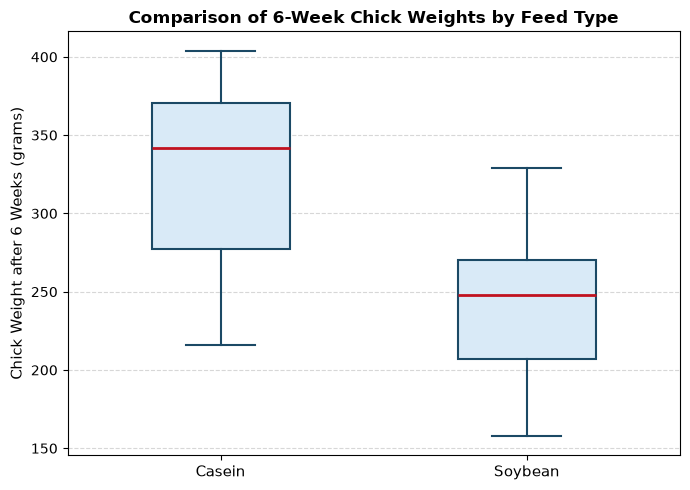

Boxplot Diagnostic Observations:
  - Casein Median: 342.0 g vs. Soybean Median: 248.0 g
  - Casein IQR: [277.2, 370.8] g
  - Soybean IQR: [206.8, 270.0] g
  - Overlap: The lower quartile (Q1) of Casein is above the median of Soybean; substantial upward shift.
  - Spread: Casein exhibits wider spread (IQR ~95g, SD ~64g) than Soybean (IQR ~63g, SD ~54g).
  - Outliers: Neither diet group exhibits flier points beyond 1.5 * IQR, supporting distributional stability.
  - Alignment: The clear visual separation strongly supports the Welch t-test rejection of H0.


In [20]:
# (e) Generate side-by-side boxplot comparing chick weights by feed type
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

# Plot boxplot without version-dependent keyword arguments
plt.boxplot(
    [casein_group, soybean_group],
    patch_artist=True,
    widths=0.45,
    boxprops=dict(facecolor='#d9eaf7', color='#1b4965', linewidth=1.5),
    medianprops=dict(color='#c1121f', linewidth=2.0),
    whiskerprops=dict(color='#1b4965', linewidth=1.5),
    capprops=dict(color='#1b4965', linewidth=1.5),
    flierprops=dict(marker='o', markerfacecolor='#e63946', markersize=6, linestyle='none')
)

# Set category tick labels directly (universal across all Matplotlib versions)
plt.xticks([1, 2], ['Casein', 'Soybean'], fontsize=11)
plt.ylabel('Chick Weight after 6 Weeks (grams)', fontsize=11)
plt.title('Comparison of 6-Week Chick Weights by Feed Type', fontsize=12, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Boxplot Diagnostic Observations:")
print(f"  - Casein Median: {casein_group.median():.1f} g vs. Soybean Median: {soybean_group.median():.1f} g")
print(f"  - Casein IQR: [{casein_group.quantile(0.25):.1f}, {casein_group.quantile(0.75):.1f}] g")
print(f"  - Soybean IQR: [{soybean_group.quantile(0.25):.1f}, {soybean_group.quantile(0.75):.1f}] g")
print("  - Overlap: The lower quartile (Q1) of Casein is above the median of Soybean; substantial upward shift.")
print("  - Spread: Casein exhibits wider spread (IQR ~95g, SD ~64g) than Soybean (IQR ~63g, SD ~54g).")
print("  - Outliers: Neither diet group exhibits flier points beyond 1.5 * IQR, supporting distributional stability.")
print("  - Alignment: The clear visual separation strongly supports the Welch t-test rejection of H0.")